In [37]:
import pandas as pd

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin']

# הטעינה הכי בטוחה לקובץ הספציפי הזה
df = pd.read_csv(url, names=column_names, na_values='?', comment='\t',
                sep=r'\s+', skipinitialspace=True, index_col=False)

print("--- בדיקה חוזרת ---")
print(df.isna().sum())
print("\n--- חמש שורות ראשונות ---")
print(df.head())

--- בדיקה חוזרת ---
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

--- חמש שורות ראשונות ---
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin  
0          70       1  
1          70       1  
2          70       1  
3          70       1  
4          70       1  


C:\Users\דוד\AppData\Local\Temp\ipykernel_11312\874531935.py:8: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(url, names=column_names, na_values='?', comment='\t',


In [38]:
# מילוי ערכים חסרים באמצעות החציון
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# בדיקה שאין יותר ערכים חסרים
print("ערכים חסרים לאחר טיפול:")
print(df.isna().sum())

ערכים חסרים לאחר טיפול:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. הפרדה ל-X ו-y
X = df.drop('mpg', axis=1) # כל העמודות חוץ מ-mpg
y = df['mpg']              # רק העמודה של mpg

# 2. חלוקה לסט אימון (80%) וסט בדיקה (20%)
# random_state=42 מבטיח שכל פעם שתריץ תקבל את אותה חלוקה
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. נרמול (Standardization)
# אנחנו מחשבים את הממוצע והסטייה רק על האימון (fit) ומחילים על שניהם (transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("הנתונים חולקו ונורמלו בהצלחה!")
print(f"גודל סט האימון: {X_train_scaled.shape[0]} דגימות")
print(f"גודל סט הבדיקה: {X_test_scaled.shape[0]} דגימות")

הנתונים חולקו ונורמלו בהצלחה!
גודל סט האימון: 318 דגימות
גודל סט הבדיקה: 80 דגימות


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. יצירת המודל ואימון שלו על הנתונים המנורמלים
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. חיזוי על סט הבדיקה (הנתונים שהמודל לא ראה)
y_pred = lr_model.predict(X_test_scaled)

# 3. חישוב המדדים שהמרצה ביקש
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- מדדי הערכה למודל ליניארי ---")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

--- מדדי הערכה למודל ליניארי ---
MSE: 8.20
RMSE: 2.86
MAE: 2.26
R2 Score: 0.85


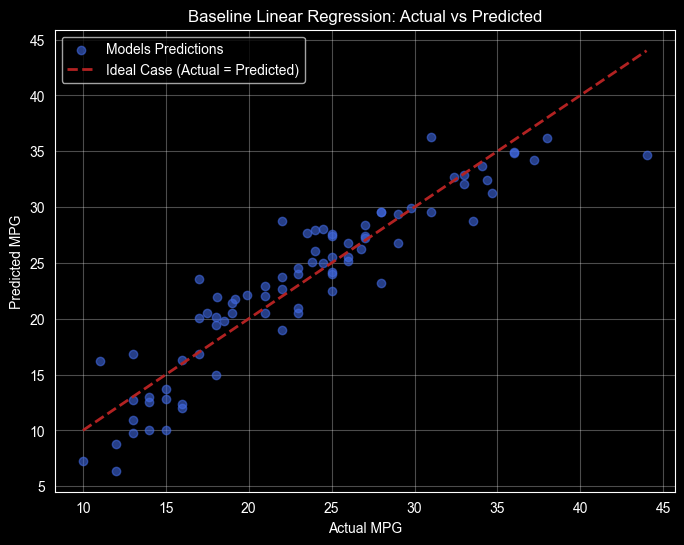

Graph saved as linear_baseline.png


In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# ציור הנקודות
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', label='Models Predictions')

# קו ה-45 מעלות (הקו האידיאלי)
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='firebrick', linestyle='--', lw=2, label='Ideal Case (Actual = Predicted)')

plt.xlabel('Actual MPG') # המציאות
plt.ylabel('Predicted MPG') # החיזוי
plt.title('Baseline Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('linear_baseline.png', dpi=300, bbox_inches='tight')
plt.show()
# אחרי הקוד של ה-plt.show() או במקומו:
print("Graph saved as linear_baseline.png")

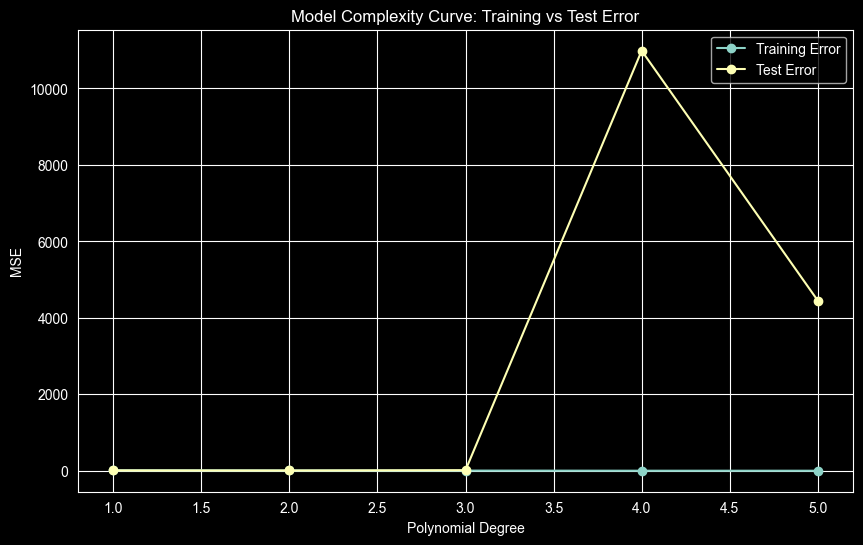

Degree 1: Train MSE = 11.66, Test MSE = 8.20
Degree 2: Train MSE = 6.76, Test MSE = 5.97
Degree 3: Train MSE = 3.65, Test MSE = 13.94
Degree 4: Train MSE = 0.22, Test MSE = 10987.75
Degree 5: Train MSE = 0.00, Test MSE = 4450.13
Graph saved as complexity_curve.png


In [42]:
from sklearn.preprocessing import PolynomialFeatures

degrees = range(1, 6)
train_errors = []
test_errors = []

for deg in degrees:
    # 1. יצירת מאפיינים פולינומיים (למשל x^2, x^3)
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    # 2. אימון מודל ליניארי על המאפיינים החדשים
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # 3. חישוב טעות (MSE) עבור אימון ובדיקה
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# 4. ציור גרף המורכבות (Complexity Curve)
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Training Error', marker='o')
plt.plot(degrees, test_errors, label='Test Error', marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Model Complexity Curve: Training vs Test Error')
plt.legend()
plt.grid(True)
plt.savefig('complexity_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# הדפסת התוצאות כדי שנראה איפה המינימום
for i, deg in enumerate(degrees):
    print(f"Degree {deg}: Train MSE = {train_errors[i]:.2f}, Test MSE = {test_errors[i]:.2f}")
print("Graph saved as complexity_curve.png")

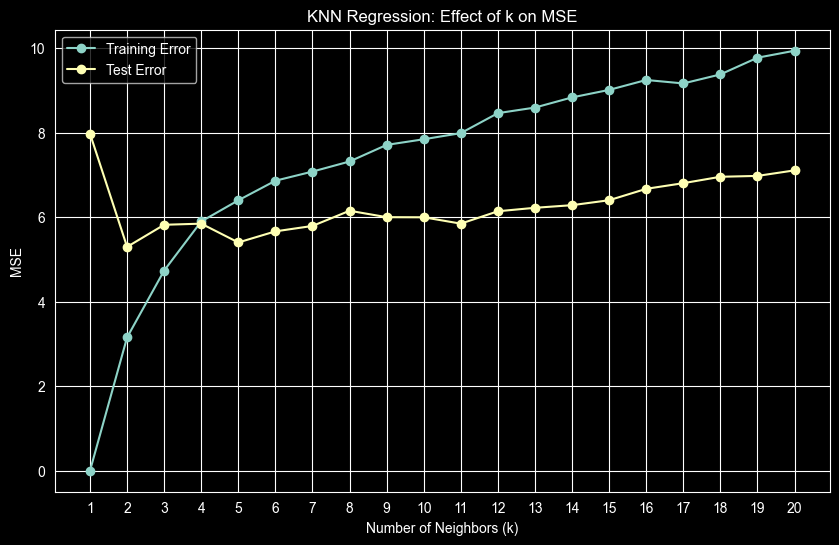

ה-k שנותן את הטעות הנמוכה ביותר בבדיקה הוא: 2
MSE בדרגה זו: 5.30
Graph saved as knn_k_effect.png


In [43]:
from sklearn.neighbors import KNeighborsRegressor

k_values = range(1, 21)
knn_train_errors = []
knn_test_errors = []

for k in k_values:
    # 1. יצירת המודל ואימון
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # 2. חיזוי
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)

    # 3. שמירת טעויות (MSE)
    knn_train_errors.append(mean_squared_error(y_train, y_train_pred))
    knn_test_errors.append(mean_squared_error(y_test, y_test_pred))

# 4. ציור גרף השפעת k על הטעות
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_train_errors, label='Training Error', marker='o')
plt.plot(k_values, knn_test_errors, label='Test Error', marker='o')
plt.xticks(k_values)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('MSE')
plt.title('KNN Regression: Effect of k on MSE')
plt.legend()
plt.grid(True)
plt.savefig('knn_k_effect.png', dpi=300, bbox_inches='tight')
plt.show()

# מציאת ה-k האופטימלי
best_k = k_values[np.argmin(knn_test_errors)]
print(f"ה-k שנותן את הטעות הנמוכה ביותר בבדיקה הוא: {best_k}")
print(f"MSE בדרגה זו: {min(knn_test_errors):.2f}")
print("Graph saved as knn_k_effect.png")

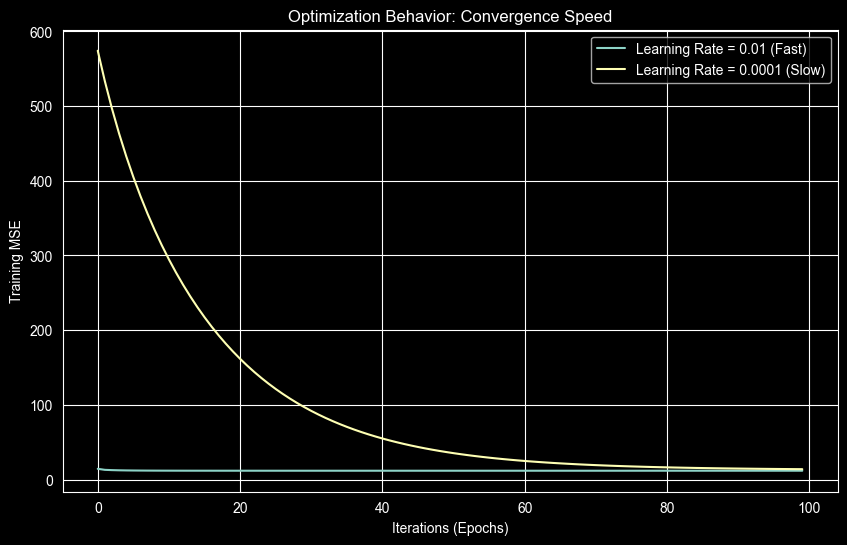

Graph saved as optimization_curve.png


In [44]:
from sklearn.linear_model import SGDRegressor

# פונקציה קטנה שעוקבת אחרי הירידה בטעות לאורך זמן
def get_learning_curve(eta0):
    model = SGDRegressor(learning_rate='constant', eta0=eta0, max_iter=1,
                         warm_start=True, random_state=42)
    errors = []
    for i in range(100): # 100 איטרציות
        model.partial_fit(X_train_scaled, y_train)
        y_pred_step = model.predict(X_train_scaled)
        errors.append(mean_squared_error(y_train, y_pred_step))
    return errors

# הרצה עבור שני קצבי למידה שונים
fast_learning = get_learning_curve(0.01)
slow_learning = get_learning_curve(0.0001)

# ציור הגרף
plt.figure(figsize=(10, 6))
plt.plot(fast_learning, label='Learning Rate = 0.01 (Fast)')
plt.plot(slow_learning, label='Learning Rate = 0.0001 (Slow)')
plt.xlabel('Iterations (Epochs)')
plt.ylabel('Training MSE')
plt.title('Optimization Behavior: Convergence Speed')
plt.legend()
plt.grid(True)
plt.savefig('optimization_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Graph saved as optimization_curve.png")

C:\Users\דוד\AppData\Local\Temp\ipykernel_11312\561360611.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f, encoding='latin1')


הנתונים נטענו בהצלחה מהתיקייה המקומית!
מספר דגימות אימון: 50000
מספר דגימות בדיקה: 10000


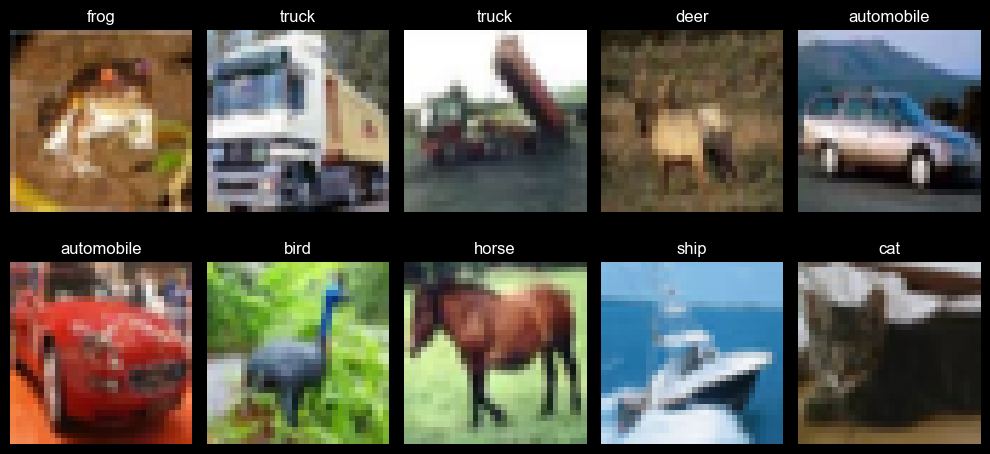

In [45]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt

def load_batch(file_path):
    with open(file_path, 'rb') as f:
        # טעינת הקובץ המקומי בפורמט שמתאים לפייתון 3
        data_dict = pickle.load(f, encoding='latin1')
    return data_dict['data'], data_dict['labels']

# הנתיב המדויק שנתת לי
data_dir = r'C:\Users\דוד\PycharmProjects\AI\cifar-10-batches-py'

try:
    # 1. טעינת כל נתוני האימון (יש 5 קבצים כאלו בתיקייה)
    X_train_list = []
    y_train_list = []
    for i in range(1, 6):
        file_path = os.path.join(data_dir, f'data_batch_{i}')
        data, labels = load_batch(file_path)
        X_train_list.append(data)
        y_train_list.append(labels)

    # איחוד כל ה-batches למערך אחד גדול
    X_train_raw = np.concatenate(X_train_list)
    y_train_raw = np.concatenate(y_train_list)

    # 2. טעינת נתוני הבדיקה (Test)
    X_test_raw, y_test_raw = load_batch(os.path.join(data_dir, 'test_batch'))
    X_test_raw = np.array(X_test_raw)
    y_test_raw = np.array(y_test_raw)

    print(f"הנתונים נטענו בהצלחה מהתיקייה המקומית!")
    print(f"מספר דגימות אימון: {X_train_raw.shape[0]}")
    print(f"מספר דגימות בדיקה: {X_test_raw.shape[0]}")

    # 3. Preprocessing: נרמול (Scaling)
    # הפיקסלים הם בין 0-255, נחלק ב-255 כדי שיהיו בטווח 0-1
    X_train_scaled = X_train_raw / 255.0
    X_test_scaled = X_test_raw / 255.0

    # 4. הצגת תמונות כדי לוודא שהכל תקין
    classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        # שינוי המבנה מוקטור (3072) חזרה לתמונה צבעונית (32x32x3)
        img = X_train_raw[i].reshape(3, 32, 32).transpose(1, 2, 0)
        plt.imshow(img)
        plt.title(classes[y_train_raw[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"שגיאה: לא מצאתי את הקבצים בנתיב: {data_dir}")
    print("וודא שחילצת את ה-zip ושהתיקייה נמצאת שם.")

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. ניקח מדגם קטן כדי שהאימון לא ייקח נצח
subset_size = 5000
X_train_sub = X_train_scaled[:subset_size]
y_train_sub = y_train_raw[:subset_size]

print(f"מתחיל אימון Logistic Regression על {subset_size} דגימות...")

# 2. יצירת המודל (ללא multi_class)
# המודל יזהה לבד שזה Multiclass
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

# 3. אימון
lr_model.fit(X_train_sub, y_train_sub)

# 4. חיזוי על סט הבדיקה המלא
y_pred_lr = lr_model.predict(X_test_scaled)

# 5. תוצאות
acc_lr = accuracy_score(y_test_raw, y_pred_lr)
print(f"Accuracy of Logistic Regression: {acc_lr:.4f}")

מתחיל אימון Logistic Regression על 5000 דגימות...
Accuracy of Logistic Regression: 0.3106


C:\Users\דוד\PycharmProjects\AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
from sklearn.svm import SVC

print(f"מתחיל אימון SVM על {subset_size} דגימות... זה עשוי לקחת דקה-שתיים")

# יצירת המודל
# kernel='rbf' מאפשר למודל למצוא קשרים לא ליניאריים (Kernel Trick)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# אימון
svm_model.fit(X_train_sub, y_train_sub)

# חיזוי
y_pred_svm = svm_model.predict(X_test_scaled)

# תוצאות
acc_svm = accuracy_score(y_test_raw, y_pred_svm)
print(f"Accuracy of SVM (RBF Kernel): {acc_svm:.4f}")

מתחיל אימון SVM על 5000 דגימות... זה עשוי לקחת דקה-שתיים
Accuracy of SVM (RBF Kernel): 0.4435


מריץ KNN על התמונות...
Accuracy of KNN on images: 0.2732


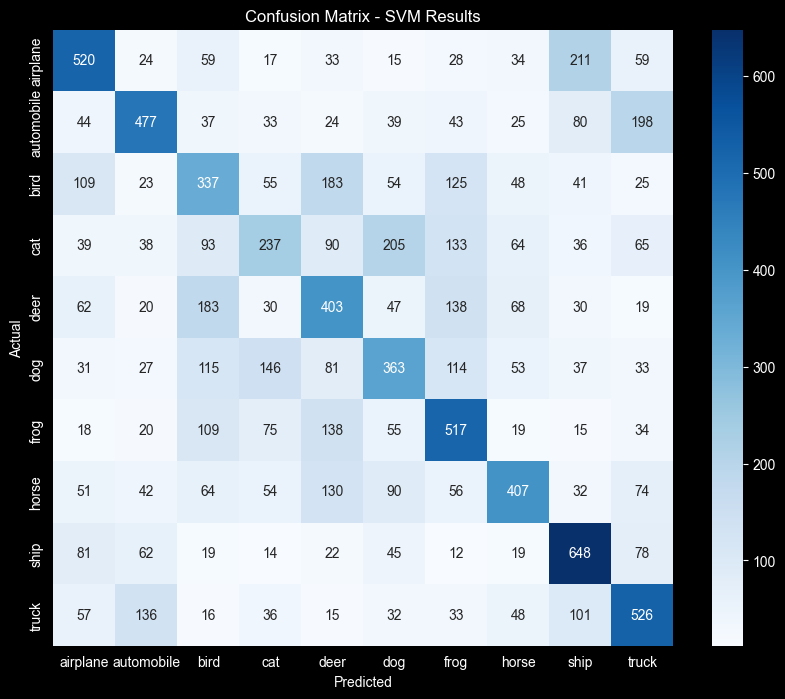

In [49]:
from sklearn import metrics
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

# א. KNN לסיווג תמונות (סעיף שמופיע בדרישות ששלחת עכשיו)
print("מריץ KNN על התמונות...")
knn_img = KNeighborsClassifier(n_neighbors=5)
knn_img.fit(X_train_sub, y_train_sub)
acc_knn_img = knn_img.score(X_test_scaled, y_test_raw)
print(f"Accuracy of KNN on images: {acc_knn_img:.4f}")

# ב. יצירת Confusion Matrix עבור המודל הכי טוב (SVM)
plt.figure(figsize=(10, 8))
cm = metrics.confusion_matrix(y_test_raw, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM Results')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()